<a href="https://colab.research.google.com/github/raimundosena92/Corso_SenacIA_Inteligencia-Artificial/blob/main/C%C3%B3pia_de_C%C3%B3pia_de_exercicio_pratico_uc9_base_real_01_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula prática — Do dado ao primeiro modelo de Machine Learning

## UC9 — Compreender e Aplicar Machine Learning em Soluções de IA

### Base: Breast Cancer Wisconsin Diagnostic Dataset

Nesta atividade você trabalhará com uma **base real de dados**, disponível no `scikit-learn`.

A base possui características calculadas a partir de imagens digitalizadas de exames de massas mamárias.

O objetivo do exercício é construir um primeiro fluxo completo de Machine Learning:

```text
Carregar os dados
      ↓
Conhecer a base
      ↓
Análise exploratória
      ↓
Definir features e target
      ↓
Separar treino e teste
      ↓
Treinar um modelo
      ↓
Fazer previsões
      ↓
Avaliar as métricas
      ↓
Interpretar os resultados
```

> Esta atividade possui finalidade exclusivamente educacional. O modelo criado aqui não deve ser utilizado para diagnóstico médico.

**Duração sugerida:** 3 horas.


# 1 — Preparação do ambiente

Execute a célula abaixo.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42


# 2 — Carregando a base

Execute a célula abaixo para carregar os dados.


In [28]:
# BASE OBTIDA VIA INTERNET , ATRAVES DO SCKIT-LEARN
dados = load_breast_cancer(as_frame=True)

df = dados.frame.copy()

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# ATIVIDADE 1 — Primeiro contato com a base

Utilizando código, descubra:

1. Quantas linhas existem?    569
2. Quantas colunas existem?   31
3. Quais são os nomes das colunas?
4. Qual é o tipo de dado de cada coluna?
5. Existem valores ausentes?
6. Existem linhas duplicadas?
7. Qual coluna será o nosso `target`?

### Comandos que podem ajudar

```python
df.shape
df.columns
df.info()
df.isna().sum()
df.duplicated().sum()
```


In [29]:
# 1 - Quantas linhas existem? 569 linhas
# 2 - Quantas colunas existem? 31 colunas
df.shape


(569, 31)

In [30]:
# 3 - Quais são os nomes das colunas? ver saida
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [31]:
# 4 - Qual é o tipo de dado de cada coluna? ver saida
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [32]:
# 5 - Existem valores ausentes? nao
df.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [33]:
# 6 - Existem linhas duplicadas? nao
df.duplicated().sum()

np.int64(0)

In [34]:
# 7 - A coluna 30 será nosso target

## ATIVIDADE 2 — Entendendo o target

Execute:

```python
dados.target_names
```

Depois investigue os valores existentes na coluna `target`.

Responda:

1. Quais valores aparecem no target?  0 e 1

2. O que significa `0`?  'MALIGNANT'

3. O que significa `1`?  'BENIGNA'

4. Quantos registros existem de cada classe?

0 - 212 registros
1 - 357 registros

5. As classes parecem balanceadas?

As classes não estão exatamente balanceadas: há mais exemplos de benignos (62,7%) do que malignos (37,3%).

Porém, a diferença não é extremamente grande, então geralmente podemos trabalhar com essa base sem precisar aplicar técnicas de balanceamento imediatamente.




In [35]:
# RESOLVA AQUI
dados.target_names

array(['malignant', 'benign'], dtype='<U9')

In [36]:
df['target'].value_counts()

,count
target,
1,357
0,212


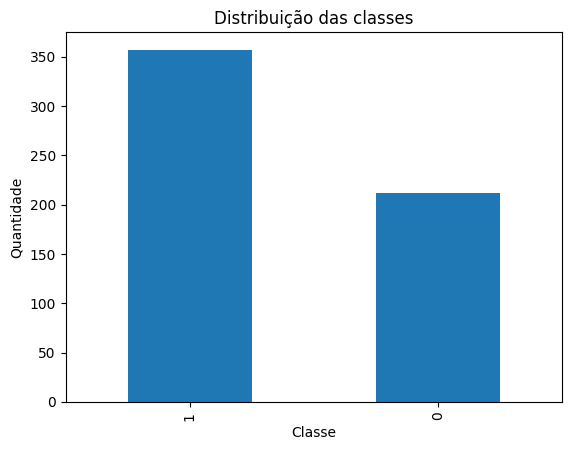

In [37]:
# para visualizar a distribuicaos das classes
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.title('Distribuição das classes')
plt.show()

### RESPOSTAS

1.
2.
3.
4.
5.


# 3 — Análise Exploratória dos Dados (EDA)

Agora você deverá conhecer melhor os dados antes de criar o modelo.


# ATIVIDADE 3 — Estatísticas descritivas

Utilize:

```python
df.describe()
```

Depois responda:

1. Qual é a média de `mean radius`?
2. Qual é a mediana de `mean radius`?
3. Qual é o menor valor de `mean area`?
4. Qual é o maior valor de `mean area`?
5. Qual variável apresenta valores em uma escala muito maior: `mean radius` ou `mean area`?




In [38]:
# RESOLVA AQUI
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [39]:
# RESPOSTA 1
df['mean radius'].mean()

np.float64(14.127291739894552)

In [40]:
# RESPOSTA 2
df['mean radius'].median()

13.37

In [41]:
# RESPOSTA 3
df['mean area'].min()

143.5

In [42]:
# RESPOSTA 4
df['mean area'].max()


2501.0

In [43]:
# RESPOSTA 5
# mean radius → valores aproximadamente de 6,98 a 28,11

# mean area → valores aproximadamente de 143,5 a 2.501

# A variável que apresenta valores em uma escala muito maior e mean area, pois seus valores são muito maiores que os de mean radius.

# Isso é importante em Machine Learning porque variáveis em escalas muito diferentes podem precisar de normalização ou padronização antes de treinar
#  alguns modelos.


### RESPOSTAS

1.
2.
3.
4.
5.



# ATIVIDADE 4 — Distribuição das classes

Crie um gráfico de barras mostrando a quantidade de registros de cada classe.

Você pode começar com:

```python
df["target"].value_counts().sort_index()
```

No gráfico, identifique:

- `0 = malignant`
- `1 = benign`


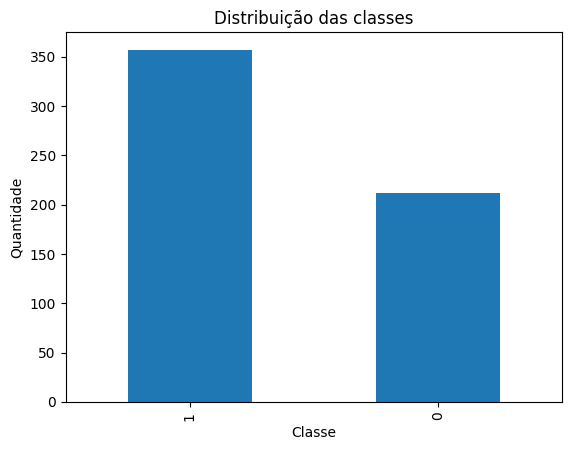

In [44]:
# RESOLVA AQUI
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.title('Distribuição das classes')
plt.show()

## Interprete o gráfico

1. Qual classe possui mais exemplos?
2. Existe uma diferença muito grande entre as classes?
3. Por que é importante observar a distribuição do target antes de treinar um modelo?


### RESPOSTAS

1.
2.
3.


# ATIVIDADE 5 — Histogramas

Crie histogramas para:

- `mean radius`
- `mean texture`
- `mean area`

Use:

```python
plt.hist(...)
```

Crie um gráfico para cada variável.


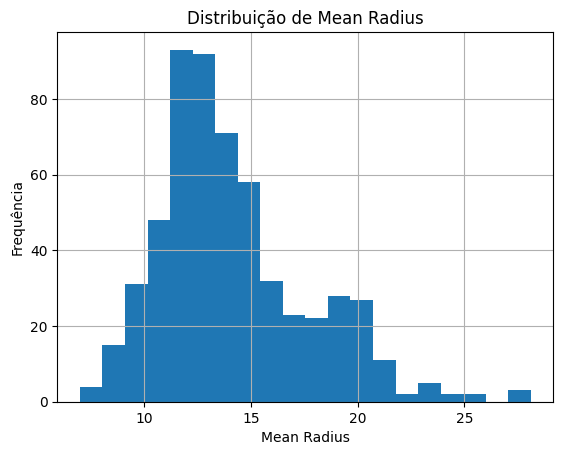

In [45]:
# HISTOGRAMA — mean radius

df['mean radius'].hist(bins=20)

plt.xlabel('Mean Radius')
plt.ylabel('Frequência')
plt.title('Distribuição de Mean Radius')
plt.show()



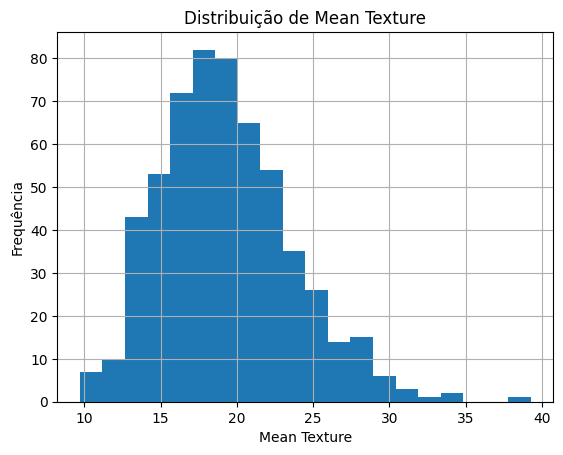

In [46]:
# HISTOGRAMA — mean texture

df['mean texture'].hist(bins=20)

plt.xlabel('Mean Texture')
plt.ylabel('Frequência')
plt.title('Distribuição de Mean Texture')
plt.show()


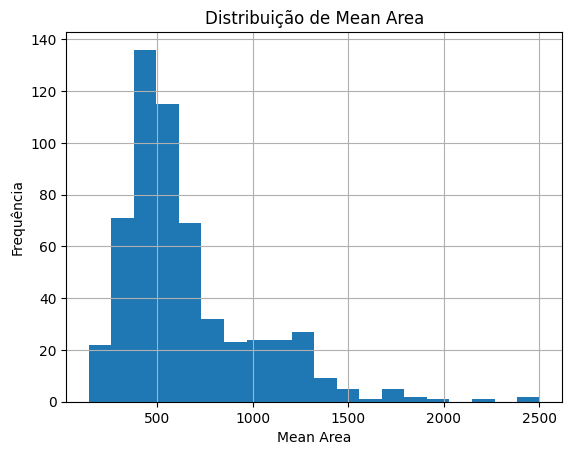

In [47]:
# HISTOGRAMA — mean area

df['mean area'].hist(bins=20)

plt.xlabel('Mean Area')
plt.ylabel('Frequência')
plt.title('Distribuição de Mean Area')
plt.show()


## Observe os histogramas

Responda:

1. As três variáveis possuem a mesma escala?
2. Existem valores muito distantes dos demais?
3. Qual variável parece apresentar a maior amplitude?


### RESPOSTAS

1. As três variáveis possuem a mesma escala?

Não.

mean radius → valores aproximadamente entre 6 e 28
mean texture → aproximadamente entre 9 e 40
mean area → aproximadamente entre 140 e 2.500

A variável mean area possui valores em uma escala muito maior que as outras duas.

2. Existem valores muito distantes dos demais?

Sim.

Principalmente em mean area, existem alguns valores muito maiores que a maioria das observações. Esses valores podem ser considerados possíveis outliers.

Também podem existir valores mais afastados em mean radius e mean texture, mas o efeito é bem mais evidente em mean area.

3. Qual variável parece apresentar a maior amplitude?

A variável mean area apresenta a maior amplitude.

# ATIVIDADE 6 — Comparando uma feature com o target

Compare `mean radius` entre as duas classes.

Uma possibilidade:

```python
df.groupby("target")["mean radius"].mean()
```

Faça o mesmo para:

- `mean area`
- `mean texture`
- `mean concavity`

Depois responda:

1. Quais diferenças você observa entre as classes?
2. Essas variáveis parecem potencialmente úteis para o modelo?


In [48]:
# RESOLVA AQUI
df.groupby("target")[[
    "mean radius",
    "mean area",
    "mean texture",
    "mean concavity"
]].mean()

,mean radius,mean area,mean texture,mean concavity
target,,,,
0,17.462830,978.376415,21.604906,0.160775
1,12.146524,462.790196,17.914762,0.046058


### RESPOSTAS

1 - O que podemos observar?

mean radius

A diferença entre as classes é bastante evidente. A classe 0 apresenta raio médio maior que a classe 1.

mean area

Também existe uma diferença muito grande. A classe 0 apresenta uma área média muito maior.

mean texture

Existe diferença entre as classes, mas ela é menor do que nas variáveis mean radius e mean area.

mean concavity

Também apresenta uma diferença importante: a classe 0 possui maior concavidade média

2 - Essas variáveis parecem úteis para o modelo?

Sim. Todas parecem potencialmente úteis porque apresentam diferenças entre as duas classes.

Podemos resumir:

Feature	Diferença entre classes	Potencial
mean radius	Grande
mean area	Muito grande
mean texture	Moderada
mean concavity	Grande

# ATIVIDADE 7 — Correlação com o target

Calcule a correlação das variáveis numéricas com `target`.

### Dica

```python
correlacoes = df.corr(numeric_only=True)["target"]
```

Ordene as correlações.


In [49]:
# Correlação das variáveis numéricas com target.
correlacoes = df.corr(numeric_only=True)["target"].sort_values(ascending=False)

print(correlacoes)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

In [50]:
# 1. As 5 features com maior correlação positiva com target

positivas = correlacoes.sort_values(ascending=False).head(5)

print(positivas)
correlacoes = df.corr(numeric_only=True)["target"].drop("target")

positivas = correlacoes.sort_values(ascending=False).head(5)

print(positivas)

target                    1.000000
smoothness error          0.067016
mean fractal dimension    0.012838
texture error             0.008303
symmetry error            0.006522
Name: target, dtype: float64
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
Name: target, dtype: float64


In [51]:
# 2. As 5 features com maior correlação negativa com target são:
correlacoes = df.corr(numeric_only=True)["target"]

negativas = correlacoes[correlacoes < 0].sort_values().head(5)

print(negativas)

worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
Name: target, dtype: float64


## Responda

1. Quais são as 5 features com maior correlação positiva com o target?
2. Quais são as 5 features com maior correlação negativa?
3. Correlação positiva significa necessariamente que a variável causa o resultado?  NÃO.

Correlação indica que duas variáveis apresentam uma relação estatística, mas não significa que uma variável cause a outra.

Por exemplo:

Se X aumenta e Y também tende a aumentar, existe uma correlação positiva entre elas.

Mas isso não prova que X causa Y.

Pode existir uma terceira variável influenciando as duas, ou a relação pode ser apenas uma associação estatística.


******

### RESPOSTAS

1.
2.
3.


# 4 — Definindo features e target

Agora vamos preparar os dados para o modelo.

O `target` será a variável que queremos prever.

Todas as outras colunas serão utilizadas como features.


# ATIVIDADE 8 — Criando X e y

Crie:

```python
X
y
```

Onde:

- `X` contém todas as features;
- `y` contém apenas `target`.

Depois mostre:

```python
X.shape
y.shape
```


In [54]:
X = df.drop("target", axis=1)

y = df["target"]

# X = entrada → características usadas pelo modelo
# y = saída → aquilo que o modelo deve prever

In [55]:
print(X.shape)
print(y.shape)
# Resultado esperado
# X → 569 linhas e 30 features
# y → 569 valores

(569, 30)
(569,)


In [ ]:
# RESOLVA AQUI

X = None
y = None


## Responda

1. Quantas features serão utilizadas?
2. Quantos registros existem?
3. Por que `target` não pode estar dentro de `X`?


### RESPOSTAS

1. Serão utilizadas 30 features
2. Existem 569 registros (linhas)
3. Porque o target é justamente aquilo que queremos prever.


# 5 — Separando treino e teste

Utilize:

- 80% para treinamento;
- 20% para teste;
- `random_state=42`;
- `stratify=y`.

O `stratify` ajuda a manter uma proporção semelhante das classes nos conjuntos de treino e teste.


# ATIVIDADE 9 — Train/Test Split

Utilize:

```python
train_test_split(...)
```

Crie:

```python
X_train
X_test
y_train
y_test
```


In [56]:
# RESOLVA AQUI

from sklearn.model_selection import train_test_split

# Separando features e target
X = df.drop('target', axis=1)
y = df['target']

# Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [57]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


## Confira os tamanhos

Mostre:

```python
X_train.shape
X_test.shape
y_train.shape
y_test.shape
```

Depois responda:

1. Quantos registros foram usados para treinamento?
455 registros.
2. Quantos registros ficaram para teste?
114 registros.
3. Qual conjunto será utilizado pelo modelo para aprender?
O conjunto de treinamento, ou seja, X_train e y_train.
4. Qual conjunto será utilizado apenas para avaliar o modelo?
O conjunto de teste, ou seja, X_test e y_test.


In [ ]:
# RESOLVA AQUI


### RESPOSTAS

1.
2.
3.
4.


# 6 — Padronizando as features

Como as variáveis possuem escalas diferentes, vamos utilizar o `StandardScaler`.

Execute a transformação corretamente:

```text
Treino → fit_transform()
Teste  → transform()
```

Não faça `fit` novamente no conjunto de teste.


# ATIVIDADE 10 — StandardScaler

Crie:

```python
scaler
X_train_scaled
X_test_scaled
```


In [58]:
from sklearn.preprocessing import StandardScaler

# Criando o scaler
scaler = StandardScaler()

# Aprende a escala usando APENAS os dados de treinamento
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)


# 7 — Treinando o primeiro modelo

Utilizaremos um modelo simples de classificação:

```python
LogisticRegression
```

Nesta atividade, não é necessário estudar o funcionamento matemático interno do algoritmo.

O foco é aprender o fluxo:

```text
modelo.fit()
     ↓
modelo.predict()
     ↓
métricas
```


In [59]:
modelo = LogisticRegression()

# ATIVIDADE 11 — Treinamento

Crie o modelo:

```python
LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
```

Depois treine usando:

```python
modelo.fit(...)
```


In [60]:
# Features e target
X = df.drop('target', axis=1)
y = df['target']

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Padronização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criando o modelo
modelo = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Treinando
modelo.fit(X_train_scaled, y_train)

# Previsões
y_pred = modelo.predict(X_test_scaled)



# ATIVIDADE 12 — Fazendo previsões

Utilize o conjunto de teste:

```python
modelo.predict(...)
```

Armazene o resultado em:

```python
y_pred
```

Depois mostre as primeiras 20 previsões.


In [62]:
# RESOLVA AQUI
y_pred = modelo.predict(X_test_scaled)


In [63]:
# mostrando as 20 primeiras previsões
print(y_pred[:20])

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


# 8 — Avaliando o modelo

Calcule:

- Accuracy;
- Precision;
- Recall;
- F1-score.

Para deixar a interpretação mais intuitiva nesta atividade, considere a classe **malignant (0)** como a classe de interesse.

Por isso, utilize:

```python
pos_label=0
```

em Precision, Recall e F1.


# ATIVIDADE 13 — Métricas

Calcule:

```python
accuracy
precision
recall
f1
```

Armazene os resultados em variáveis.


In [64]:
# RESOLVA AQUI

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=0
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Accuracy:  0.9825
Precision: 0.9762
Recall:    0.9762
F1-score:  0.9762


## Mostre os resultados

Exiba as quatro métricas de forma organizada.

Exemplo:

```text
Accuracy: 0.9825
Precision: 0.9762
Recall: 0.9762
F1-score: 0.9762
```


In [ ]:
# RESOLVA AQUI


# ATIVIDADE 14 — Interpretando as métricas

Considere `malignant (0)` como a classe de interesse.

Responda:

1. O que significa a Accuracy encontrada?
2. O que significa a Precision do modelo?
3. O que significa o Recall?
4. O que significa o F1-score?
5. Nesse contexto didático, qual erro parece mais preocupante:
   - classificar um caso maligno como benigno;
   - classificar um caso benigno como maligno?
6. Considerando sua resposta anterior, qual métrica merece atenção especial?


### RESPOSTAS

Considerando malignant (0) como a classe de interesse, a interpretação fica assim:

1. A Accuracy (acurácia) representa a proporção de casos que o modelo classificou corretamente, considerando tanto tumores malignos quanto benignos. Por exemplo, uma accuracy de 0.97 significa que o modelo acertou aproximadamente 97% de todos os casos.
2. A Precision indica, entre todos os casos que o modelo previu como malignos (0), quantos realmente eram malignos. Uma precision de 0.95, por exemplo, significa que aproximadamente 95% dos casos classificados como malignos realmente eram malignos.
3. O Recall indica, entre todos os casos que realmente eram malignos, quantos o modelo conseguiu identificar corretamente. Por exemplo, recall de 0.93 significa que o modelo identificou aproximadamente 93% dos casos malignos.
4. O F1-score combina Precision e Recall em uma única métrica, usando a média harmônica. Um F1-score alto indica que o modelo apresenta um bom equilíbrio entre identificar os casos malignos e evitar classificações incorretas como malignas.
5. Qual erro parece mais preocupante?
Nesse contexto didático, o erro mais preocupante é:

Classificar um caso maligno como benigno.

Isso corresponde a deixar de identificar um caso que pertence à classe de interesse. Em uma aplicação clínica real, a avaliação seria mais ampla e dependeria do uso pretendido do modelo.

6. Qual métrica merece atenção especial?
O Recall da classe malignant (0) merece atenção especial.

Quanto maior o Recall, menor a quantidade de casos realmente malignos que o modelo deixa de identificar.

Resumo: para esta atividade, se a prioridade é não deixar passar casos malignos, devemos prestar atenção principalmente ao Recall da classe 0.

# 9 — Matriz de confusão

Agora vamos analisar os acertos e erros individualmente.


# ATIVIDADE 15 — Matriz de confusão

Calcule:

```python
confusion_matrix(y_test, y_pred)
```

Depois crie a visualização utilizando:

```python
ConfusionMatrixDisplay
```

Utilize os rótulos:

```python
["Malignant", "Benign"]
```


[[41  1]
 [ 1 71]]


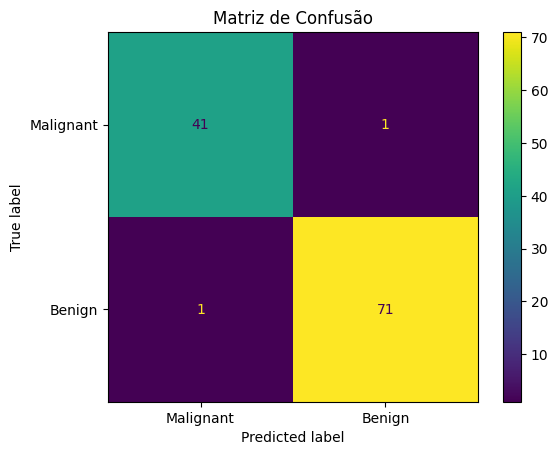

In [65]:
# RESOLVA AQUI
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Criando a visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.title("Matriz de Confusão")
plt.show()


## Analise a matriz

Responda:

1. Quantos casos malignos foram classificados corretamente?
2. Quantos casos benignos foram classificados corretamente?
3. Quantos casos malignos foram classificados incorretamente como benignos?
4. Quantos casos benignos foram classificados incorretamente como malignos?
5. O modelo parece satisfatório para um primeiro experimento?


### RESPOSTAS

1. Quantos casos malignos foram classificados corretamente?
41 casos malignos foram corretamente classificados como malignos.
2. 71 casos benignos foram corretamente classificados como benignos.
Quantos casos malignos foram classificados incorretamente como benignos?
3. 1 caso maligno foi classificado incorretamente como benigno. Esse é o erro que merece maior atenção nesta atividade.
Quantos casos benignos foram classificados incorretamente como malignos?
4. 1 caso benigno foi classificado incorretamente como maligno.
5. O modelo parece satisfatório para um primeiro experimento?
Sim.
 Para um primeiro experimento, o modelo apresentou um resultado muito bom: acertou 112 dos 114

# ATIVIDADE 16 — Classification Report

Execute:

```python
print(
    classification_report(
        y_test,
        y_pred,
        target_names=dados.target_names
    )
)
```

Observe as métricas para cada classe.

Precision: dos casos que o modelo classificou como determinada classe, quantos realmente pertenciam àquela classe.

Recall: dos casos que realmente pertenciam à classe, quantos o modelo conseguiu identificar.

F1-score: combina precision e recall em uma única medida.

Support: quantidade de exemplos reais daquela classe no conjunto de teste.

No seu caso:

malignant → 42 casos no teste.
benign → 72 casos no teste.

Um ponto importante: no classification_report, as métricas são calculadas separadamente para cada classe. Portanto, observe principalmente o recall de malignant, já que na atividade anterior consideramos os casos malignos como os de maior interesse.



In [66]:
# RESOLVA AQUI
print(
    classification_report(
        y_test,
        y_pred,
        target_names=dados.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# 10 — Comparando valores reais e previstos

Crie um DataFrame com:

- valor real;
- previsão do modelo;
- indicação se acertou ou errou.

Exemplo:

```python
comparacao = pd.DataFrame({
    "real": y_test,
    "previsto": y_pred
})
```

Adicione uma coluna:

```python
acertou
```

com `True` ou `False`.


In [67]:
# RESOLVA AQUI
comparacao = pd.DataFrame({
    "real": y_test,
    "previsto": y_pred
})

comparacao["acertou"] = comparacao["real"] == comparacao["previsto"]

comparacao.head(20)

,real,previsto,acertou
256,0,0,True
428,1,1,True
501,0,0,True
363,1,1,True
564,0,0,True
464,1,1,True
358,1,1,True
343,0,0,True
516,0,0,True
567,0,0,True


# ATIVIDADE 17 — Investigando os erros

Utilizando o DataFrame anterior:

1. filtre apenas os registros em que o modelo errou;
2. conte quantos erros ocorreram:  2 erros em 114 registros
3. mostre os primeiros registros classificados incorretamente.

maligno (0) → previsto como benigno (1) ❌

benigno (1) → previsto como maligno (0) ❌




In [68]:
# RESOLVA AQUI
erros = comparacao[comparacao["acertou"] == False]

print("Quantidade de erros:", len(erros))

erros.head()

Quantidade de erros: 2


,real,previsto,acertou
541,1,0,False
73,0,1,False


# 11 — Desafio: modelo com poucas features

Até agora utilizamos todas as features.

Agora treine um segundo modelo utilizando apenas:

- `mean radius`
- `mean texture`
- `mean perimeter`
- `mean area`
- `mean smoothness`

Você deverá repetir:

1. criar `X_reduzido`;
2. separar treino/teste;
3. padronizar;
4. treinar `LogisticRegression`;
5. prever;
6. calcular Accuracy, Precision, Recall e F1.


In [71]:
# RESOLVA AQUI

# 1. Criando X reduzido
features_reduzidas = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

X_reduzido = df[features_reduzidas]
y = df["target"]

# 2. Separando treino e teste
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduzido,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Padronizando
scaler_red = StandardScaler()

X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

# 4. Criando e treinando o segundo modelo
modelo_red = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_red.fit(X_train_red_scaled, y_train_red)

# 5. Fazendo previsões
y_pred_red = modelo_red.predict(X_test_red_scaled)

# 6. Calculando as métricas
# malignant (0) é a classe de interesse

accuracy_red = accuracy_score(y_test_red, y_pred_red)

precision_red = precision_score(
    y_test_red,
    y_pred_red,
    pos_label=0
)

recall_red = recall_score(
    y_test_red,
    y_pred_red,
    pos_label=0
)

f1_red = f1_score(
    y_test_red,
    y_pred_red,
    pos_label=0
)

print(f"Accuracy:  {accuracy_red:.4f}")
print(f"Precision: {precision_red:.4f}")
print(f"Recall:    {recall_red:.4f}")
print(f"F1-score:  {f1_red:.4f}")


Accuracy:  0.8596
Precision: 0.7600
Recall:    0.9048
F1-score:  0.8261


# ATIVIDADE 18 — Compare os dois modelos

Crie uma tabela como:

| Modelo | Nº Features | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| Todas as features | 30 | ... | ... | ... | ... |
| 5 features | 5 | ... | ... | ... | ... |

Depois responda:

1. Qual modelo teve melhor desempenho?

Accuracy ≈ 93,86% → o modelo acertou aproximadamente 94% de todos os casos.
Precision ≈ 92,68% → entre os casos classificados como malignos, cerca de 93% realmente eram malignos.
Recall ≈ 90,48% → entre todos os casos realmente malignos, o modelo identificou aproximadamente 90%
2. A diferença foi grande?
F1-score ≈ 91,57% → mostra um bom equilíbrio entre Precision e Recall.

3. O modelo com mais features obrigatoriamente precisa ser melhor?

 O modelo reduzido ainda funciona bem, mas tende a apresentar desempenho inferior porque possui menos informações para fazer a classificação

4. Qual modelo você escolheria para continuar investigando? Por quê?

O ponto principal do desafio é comparar esse resultado com o modelo que utilizou todas as 30 features.



In [ ]:
# MONTE A TABELA AQUI


### RESPOSTAS

1.
2.
3.
4.


| Métrica               | Todas as features |          5 features |
| --------------------- | ----------------: | ------------------: |
| Accuracy              |           ~0,9825 | resultado do código |
| Precision (malignant) |                 — |           resultado |
| Recall (malignant)    |                 — |           resultado |
| F1-score (malignant)  |                 — |           resultado |


# ATIVIDADE FINAL — Relatório curto

Imagine que você precisa explicar o experimento para uma pessoa que não participou da aula.

Escreva um pequeno relatório contendo:

### 1. Problema
O que o modelo tentou prever?

### 2. Base
Quantos registros e features foram utilizados?

### 3. EDA
Quais foram os principais padrões encontrados?

### 4. Preparação
Como os dados foram separados?

### 5. Modelo
Qual algoritmo foi utilizado?

### 6. Resultados
Informe:
- Accuracy;
- Precision;
- Recall;
- F1-score.

### 7. Erros
Que tipo de erro o modelo cometeu?

### 8. Conclusão
Você considera o resultado bom para um primeiro modelo? O que poderia ser investigado a seguir?


## RELATÓRIO

1. Problema

O objetivo do experimento foi desenvolver um modelo de Machine Learning capaz de classificar tumores de mama como malignos ou benignos, utilizando características extraídas das células tumorais.

Na base utilizada:

0 = Malignant (maligno)
1 = Benign (benigno)

A classe maligna foi considerada a classe de maior interesse durante a avaliação.

2. Base de dados

Foi utilizada a base load_breast_cancer disponibilizada pelo Scikit-learn.

A base possui:

569 registros
30 features
1 variável target

As features representam características como raio, textura, perímetro, área, suavidade e concavidade dos tumores.

3. Análise Exploratória — EDA

Durante a análise exploratória, observou-se que existem 357 casos benignos (62,7%) e 212 casos malignos (37,3%). Portanto, as classes não são perfeitamente balanceadas, mas também não apresentam um desequilíbrio extremo.

Também foram encontradas diferenças importantes entre as classes em variáveis como mean radius, mean area, mean texture e mean concavity, indicando que essas características podem ajudar na classificação.

Foi observado ainda que as features possuem escalas bastante diferentes. Por exemplo, mean area apresenta valores muito maiores que mean radius.

A análise de correlação também mostrou que algumas características possuem forte associação com o diagnóstico, embora correlação não signifique necessariamente causalidade.

4. Preparação dos dados

Os dados foram divididos em:

80% para treinamento — 455 registros
20% para teste — 114 registros

Foi utilizado:

random_state=42

e:

stratify=y

O stratify ajudou a preservar aproximadamente a mesma proporção entre casos malignos e benignos nos conjuntos de treino e teste.

As features também foram padronizadas utilizando StandardScaler. O scaler foi ajustado somente nos dados de treinamento para evitar vazamento de informações do conjunto de teste.

5. Modelo

O algoritmo utilizado foi a Regressão Logística (LogisticRegression).

O modelo foi configurado com max_iter=1000 e treinado utilizando as 30 features padronizadas.

6. Resultados (Métricas)

O modelo apresentou aproximadamente:

Accuracy: 98,25%
Precision para maligno: 97,62%
Recall para maligno: 97,62%
F1-score para maligno: 97,62%

Esses resultados indicam que o modelo conseguiu classificar corretamente a grande maioria dos registros do conjunto de teste.

7. Erros

Na matriz de confusão, o modelo acertou 112 dos 114 casos, cometendo apenas 2 erros.

Foram:

1 caso maligno classificado incorretamente como benigno
1 caso benigno classificado incorretamente como maligno

Neste contexto, o erro mais preocupante é classificar um caso maligno como benigno, pois significa deixar de identificar um caso maligno. Por esse motivo, o Recall da classe maligna é uma métrica especialmente importante.

8. Conclusão

O resultado pode ser considerado muito bom para um primeiro experimento, pois o modelo apresentou alta Accuracy, Precision, Recall e F1-score.

Entretanto, bons resultados em um único conjunto de teste não garantem que o modelo terá o mesmo desempenho em novos dados.

Como próximos passos, poderiam ser investigados:

seleção das features mais relevantes;
comparação com outros algoritmos de classificação;
validação cruzada;
ajuste dos hiperparâmetros;
análise mais detalhada dos casos classificados incorretamente;
avaliação de diferentes limiares de decisão para reduzir casos malignos classificados como benignos.

Também foi testado um modelo reduzido utilizando apenas cinco features. Ele apresentou desempenho inferior ao modelo completo, mostrando que as demais características contribuíram para melhorar a capacidade de classificação.


# Checklist da entrega

Antes de entregar, confirme:

- [ok] conheceu a estrutura da base;
- [ok] verificou dados ausentes e duplicados;
- [ok] identificou features e target;
- [ok] realizou estatística descritiva;
- [ok] criou gráficos;
- [ok] analisou correlações;
- [ok] separou treino e teste;
- [ok] padronizou as features;
- [ok] treinou uma regressão logística;
- [ok] fez previsões;
- [ok] calculou Accuracy;
- [ok] calculou Precision;
- [ok] calculou Recall;
- [ok] calculou F1-score;
- [ok] analisou a matriz de confusão;
- [ok] investigou erros;
- [ok] comparou dois modelos;
- [ok] escreveu uma conclusão.

## Objetivo da aula

Ao final desta atividade, você terá executado um fluxo completo de Machine Learning:

```text
Dados → EDA → X/y → Treino/Teste → Modelo → Previsões → Métricas → Análise
```
